In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import Perceptron, LogisticRegression, SGDClassifier
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, PowerTransformer

from src.auxiliares import dataframe_coeficientes
from src.config import DADOS_LIMPOS
from src.graficos import plot_coeficientes, plot_comparar_metricas_modelos
from src.models import RANDOM_STATE
from src.models import(
    grid_search_cv_classificador,
    treinar_e_validar_modelo_classificacao,
    organiza_resultados,
)

sns.set_theme(palette="bright")

In [2]:
df = pd.read_parquet(DADOS_LIMPOS)

df.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1001.0,153.40,2019.0,0.27760,0.04904,0.6656,0.14710,0.01587,0.2654,0.3001,...,25.38,0.11840,0.006399,0.1622,0.2419,0.03003,0.4601,10.38,0.9053,17.33
1,1326.0,74.08,1956.0,0.07864,0.01308,0.1866,0.07017,0.01340,0.1860,0.0869,...,24.99,0.08474,0.005225,0.1238,0.1812,0.01389,0.2750,17.77,0.7339,23.41
2,1203.0,94.03,1709.0,0.15990,0.04006,0.4245,0.12790,0.02058,0.2430,0.1974,...,23.57,0.10960,0.006150,0.1444,0.2069,0.02250,0.3613,21.25,0.7869,25.53
3,386.1,27.23,567.7,0.28390,0.07458,0.8663,0.10520,0.01867,0.2575,0.2414,...,14.91,0.14250,0.009110,0.2098,0.2597,0.05963,0.6638,20.38,1.1560,26.50
4,1297.0,94.44,1575.0,0.13280,0.02461,0.2050,0.10430,0.01885,0.1625,0.1980,...,22.54,0.10030,0.011490,0.1374,0.1809,0.01756,0.2364,14.34,0.7813,16.67


In [3]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

In [4]:
le = LabelEncoder()

y = le.fit_transform(y)

y[:20]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [5]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [6]:
preprocessamento = Pipeline(
    steps=[("scaler", PowerTransformer())]
)

In [7]:
classificadores = {

    "DummyClassifier": {
        "preprocessor": None,
        "classificador": DummyClassifier(strategy="stratified")
    },

    "Perceptron": {
        "preprocessor": preprocessamento,
        "classificador": Perceptron()
    },

    "LogisticRegression": {
        "preprocessor": preprocessamento,
        "classificador": LogisticRegression()
    },

    "SGDClassifier": {
        "preprocessor": preprocessamento,
        "classificador": SGDClassifier()
    },

}

In [8]:
resultados = {
    nome_modelo: treinar_e_validar_modelo_classificacao(X, y, kf, **classificador)
    for nome_modelo, classificador in classificadores.items()
}

df_resultados = organiza_resultados(resultados)

df_resultados

c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\linear_model\_logistic.py:455: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


,model,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
0,DummyClassifier,0.002058,0.01248,0.640351,0.614969,0.517647,0.52381,0.511628,0.421553,0.352066,0.014538
1,DummyClassifier,0.0,0.011364,0.491228,0.458565,0.325581,0.325581,0.325581,0.495906,0.375295,0.011364
2,DummyClassifier,0.001029,0.007919,0.578947,0.547619,0.428571,0.428571,0.428571,0.477183,0.358595,0.008948
3,DummyClassifier,0.001394,0.007368,0.605263,0.553571,0.4,0.454545,0.357143,0.511905,0.374205,0.008762
4,DummyClassifier,0.001001,0.009969,0.513274,0.476526,0.337349,0.341463,0.333333,0.497653,0.370595,0.010969
5,Perceptron,0.062435,0.018424,0.947368,0.953161,0.933333,0.893617,0.976744,0.992139,0.98945,0.08086
6,Perceptron,0.091347,0.014497,0.964912,0.96266,0.953488,0.953488,0.953488,0.99869,0.997909,0.105844
7,Perceptron,0.06037,0.014939,0.947368,0.943452,0.928571,0.928571,0.928571,0.982474,0.977233,0.075309
8,Perceptron,0.048905,0.014082,0.973684,0.979167,0.965517,0.933333,1.0,1.0,1.0,0.062987
9,Perceptron,0.050354,0.014122,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.064476


In [9]:
df_resultados.groupby("model").mean().sort_values("test_recall")

,fit_time,score_time,test_accuracy,test_balanced_accuracy,test_f1,test_precision,test_recall,test_roc_auc,test_average_precision,time_seconds
model,,,,,,,,,,
DummyClassifier,0.001096,0.00982,0.565813,0.53025,0.40183,0.414794,0.391251,0.48084,0.366151,0.010916
LogisticRegression,0.07216,0.01712,0.975408,0.970873,0.96636,0.981258,0.952935,0.996632,0.995721,0.089279
SGDClassifier,0.051672,0.012812,0.973669,0.972235,0.964646,0.963998,0.966888,0.995646,0.9939,0.064485
Perceptron,0.062682,0.015213,0.966667,0.967688,0.956182,0.941802,0.971761,0.99466,0.992919,0.077895


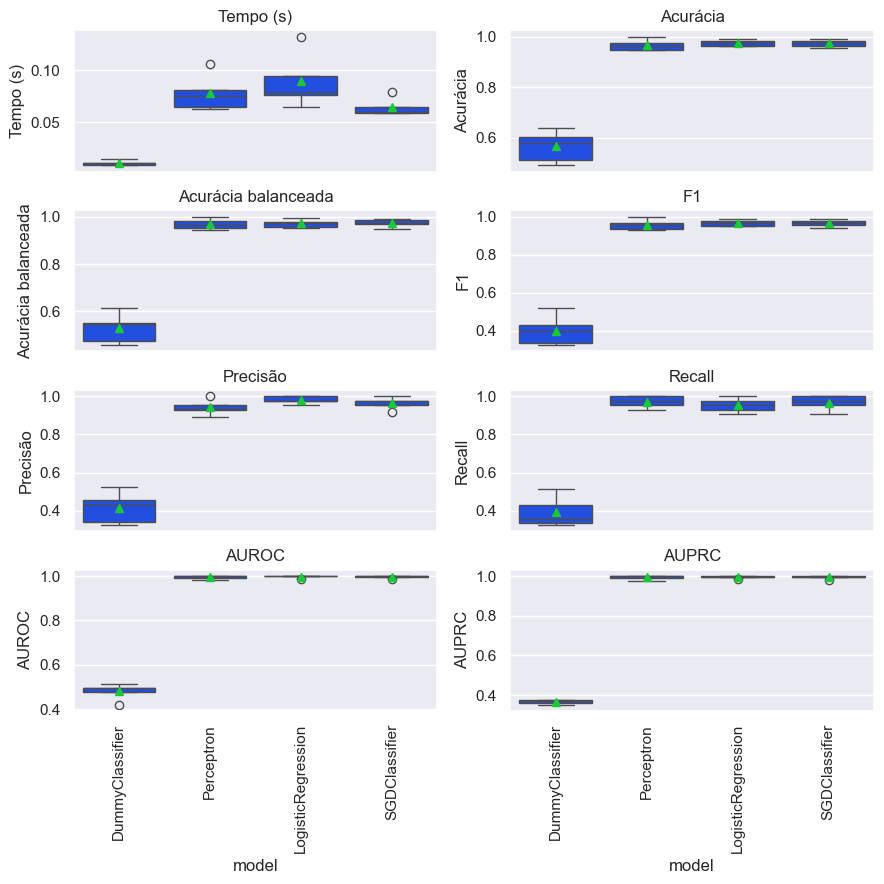

In [10]:
plot_comparar_metricas_modelos(df_resultados)

In [11]:
param_grid = {
    "clf__C": [0.1, 1, 10, 100],
    "clf__penalty": ["11", "12", "elasticnet", None],
    "clf__class_weight": [None, "balanced"],
    "clf__l1_ratio": [ 0.1, 0.25, 0.5, 0.75, 0.9],
}

In [12]:
clf = LogisticRegression(solver="saga", random_state=RANDOM_STATE)

grid_search = grid_search_cv_classificador(
    clf, param_grid, kf, preprocessamento, refit_metric="recall"
)

grid_search

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        Pipeline(steps=[('scaler',
                                                         PowerTransformer())])),
                                       ('clf',
                                        LogisticRegression(random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__class_weight': [None, 'balanced'],
                         'clf__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'clf__penalty': ['11', '12', 'elasticnet', None]},
             refit='recall',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [13]:
grid_search.fit(X, y)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
400 fits failed out of a total of 800.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
71 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\carol\anaconda3\envs\machine_learning\Lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\carol\anaconda3\envs\machine_learn

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        Pipeline(steps=[('scaler',
                                                         PowerTransformer())])),
                                       ('clf',
                                        LogisticRegression(random_state=42,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'clf__C': [0.1, 1, 10, 100],
                         'clf__class_weight': [None, 'balanced'],
                         'clf__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9],
                         'clf__penalty': ['11', '12', 'elasticnet', None]},
             refit='recall',
             scoring=['accuracy', 'balanced_accuracy', 'f1', 'precision',
                      'recall', 'roc_auc', 'average_precision'],
             verbose=1)

In [14]:
grid_search.best_params_

{'clf__C': 0.1,
 'clf__class_weight': 'balanced',
 'clf__l1_ratio': 0.1,
 'clf__penalty': 'elasticnet'}

In [15]:
grid_search.best_score_

np.float64(0.9623477297895903)

In [16]:
grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', PowerTransformer())])),
                ('clf',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    l1_ratio=0.1, penalty='elasticnet',
                                    random_state=42, solver='saga'))])

In [17]:
grid_search.best_estimator_["preprocessor"].get_feature_names_out()

array(['area_mean', 'area_se', 'area_worst', 'compactness_mean',
       'compactness_se', 'compactness_worst', 'concave points_mean',
       'concave points_se', 'concave points_worst', 'concavity_mean',
       'concavity_se', 'concavity_worst', 'fractal_dimension_mean',
       'fractal_dimension_se', 'fractal_dimension_worst',
       'perimeter_mean', 'perimeter_se', 'perimeter_worst', 'radius_mean',
       'radius_se', 'radius_worst', 'smoothness_mean', 'smoothness_se',
       'smoothness_worst', 'symmetry_mean', 'symmetry_se',
       'symmetry_worst', 'texture_mean', 'texture_se', 'texture_worst'],
      dtype=object)

In [18]:
grid_search.best_estimator_["clf"].coef_

array([[ 0.28761118,  0.50810655,  0.46182252,  0.        , -0.27288011,
         0.02824738,  0.49002609,  0.05612602,  0.46806153,  0.40825115,
         0.        ,  0.45507651, -0.13644354, -0.20498001,  0.04861954,
         0.25880344,  0.26219477,  0.39332385,  0.25891382,  0.41312464,
         0.43088278,  0.15313302, -0.00485166,  0.42614648,  0.11263209,
        -0.33069446,  0.39571425,  0.47740336, -0.0113127 ,  0.58533727]])

In [19]:
coefs = dataframe_coeficientes(
    grid_search.best_estimator_["clf"].coef_[0],
    grid_search.best_estimator_["preprocessor"].get_feature_names_out()
)

coefs

,coeficiente
symmetry_se,-0.330694
compactness_se,-0.272880
fractal_dimension_se,-0.204980
fractal_dimension_mean,-0.136444
texture_se,-0.011313
smoothness_se,-0.004852
concavity_se,0.000000
compactness_mean,0.000000
compactness_worst,0.028247
fractal_dimension_worst,0.048620


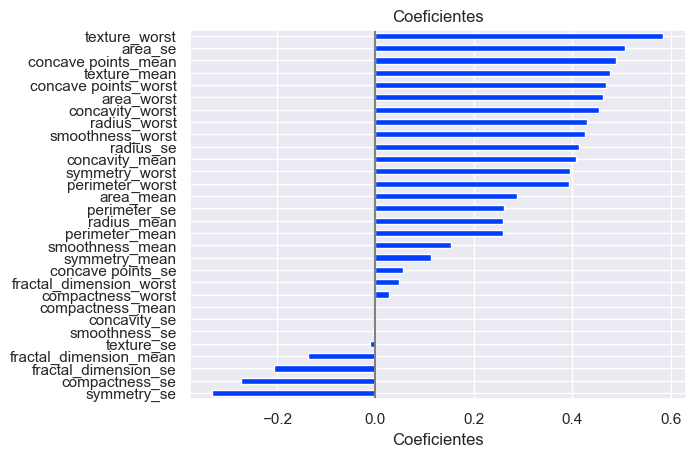

In [20]:
plot_coeficientes(coefs)

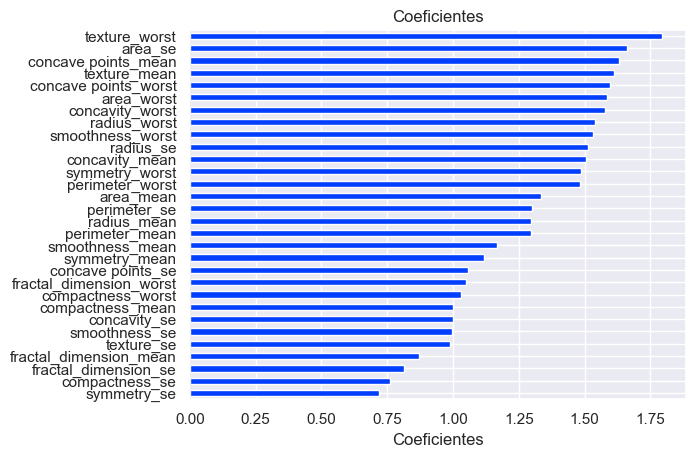

In [21]:
coefs_odds = coefs.copy()
coefs_odds["coeficiente"] = np.exp(coefs_odds["coeficiente"])

plot_coeficientes(coefs_odds)

In [22]:
coefs_odds

,coeficiente
symmetry_se,0.718425
compactness_se,0.761184
fractal_dimension_se,0.814664
fractal_dimension_mean,0.872456
texture_se,0.988751
smoothness_se,0.995160
concavity_se,1.000000
compactness_mean,1.000000
compactness_worst,1.028650
fractal_dimension_worst,1.049821


In [23]:
X_scaled = grid_search.best_estimator_["preprocessor"].transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=grid_search.best_estimator_["preprocessor"].get_feature_names_out())

X_scaled.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,radius_worst,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst
0,1.126421,1.876109,1.652210,2.165938,1.445854,1.942737,1.848558,0.810200,1.935654,1.862988,...,1.619635,1.504114,-0.030553,1.282792,1.953067,1.355589,2.197206,-2.678666,-0.498201,-1.488367
1,1.633946,1.276861,1.610022,-0.384102,-0.793830,-0.296580,0.820609,0.426936,1.101594,0.291976,...,1.578689,-0.820227,-0.633991,-0.325080,0.102291,-1.028611,-0.121997,-0.264377,-0.998312,-0.288382
2,1.461645,1.496107,1.425307,1.163977,1.121521,1.209701,1.683104,1.423361,1.722744,1.403673,...,1.419757,0.963977,-0.148581,0.580301,0.985668,0.568436,1.218181,0.547806,-0.833982,0.071406
3,-0.836238,0.045515,-0.436860,2.197843,1.964874,2.282276,1.423004,1.191720,1.862378,1.642391,...,-0.083692,2.781494,0.975445,2.857821,2.360528,2.350939,3.250202,0.357721,0.097022,0.228089
4,1.595120,1.499885,1.309486,0.762392,0.253010,-0.131829,1.410929,1.214491,0.807077,1.407479,...,1.293727,0.343932,1.545561,0.284367,0.090964,-0.227814,-0.943554,-1.233520,-0.850908,-1.637882


In [24]:
df_scaled = pd.concat([X_scaled, pd.Series(y, name="diagnosis")], axis=1)

df_scaled.head()

,area_mean,area_se,area_worst,compactness_mean,compactness_se,compactness_worst,concave points_mean,concave points_se,concave points_worst,concavity_mean,...,smoothness_mean,smoothness_se,smoothness_worst,symmetry_mean,symmetry_se,symmetry_worst,texture_mean,texture_se,texture_worst,diagnosis
0,1.126421,1.876109,1.652210,2.165938,1.445854,1.942737,1.848558,0.810200,1.935654,1.862988,...,1.504114,-0.030553,1.282792,1.953067,1.355589,2.197206,-2.678666,-0.498201,-1.488367,1
1,1.633946,1.276861,1.610022,-0.384102,-0.793830,-0.296580,0.820609,0.426936,1.101594,0.291976,...,-0.820227,-0.633991,-0.325080,0.102291,-1.028611,-0.121997,-0.264377,-0.998312,-0.288382,1
2,1.461645,1.496107,1.425307,1.163977,1.121521,1.209701,1.683104,1.423361,1.722744,1.403673,...,0.963977,-0.148581,0.580301,0.985668,0.568436,1.218181,0.547806,-0.833982,0.071406,1
3,-0.836238,0.045515,-0.436860,2.197843,1.964874,2.282276,1.423004,1.191720,1.862378,1.642391,...,2.781494,0.975445,2.857821,2.360528,2.350939,3.250202,0.357721,0.097022,0.228089,1
4,1.595120,1.499885,1.309486,0.762392,0.253010,-0.131829,1.410929,1.214491,0.807077,1.407479,...,0.343932,1.545561,0.284367,0.090964,-0.227814,-0.943554,-1.233520,-0.850908,-1.637882,1


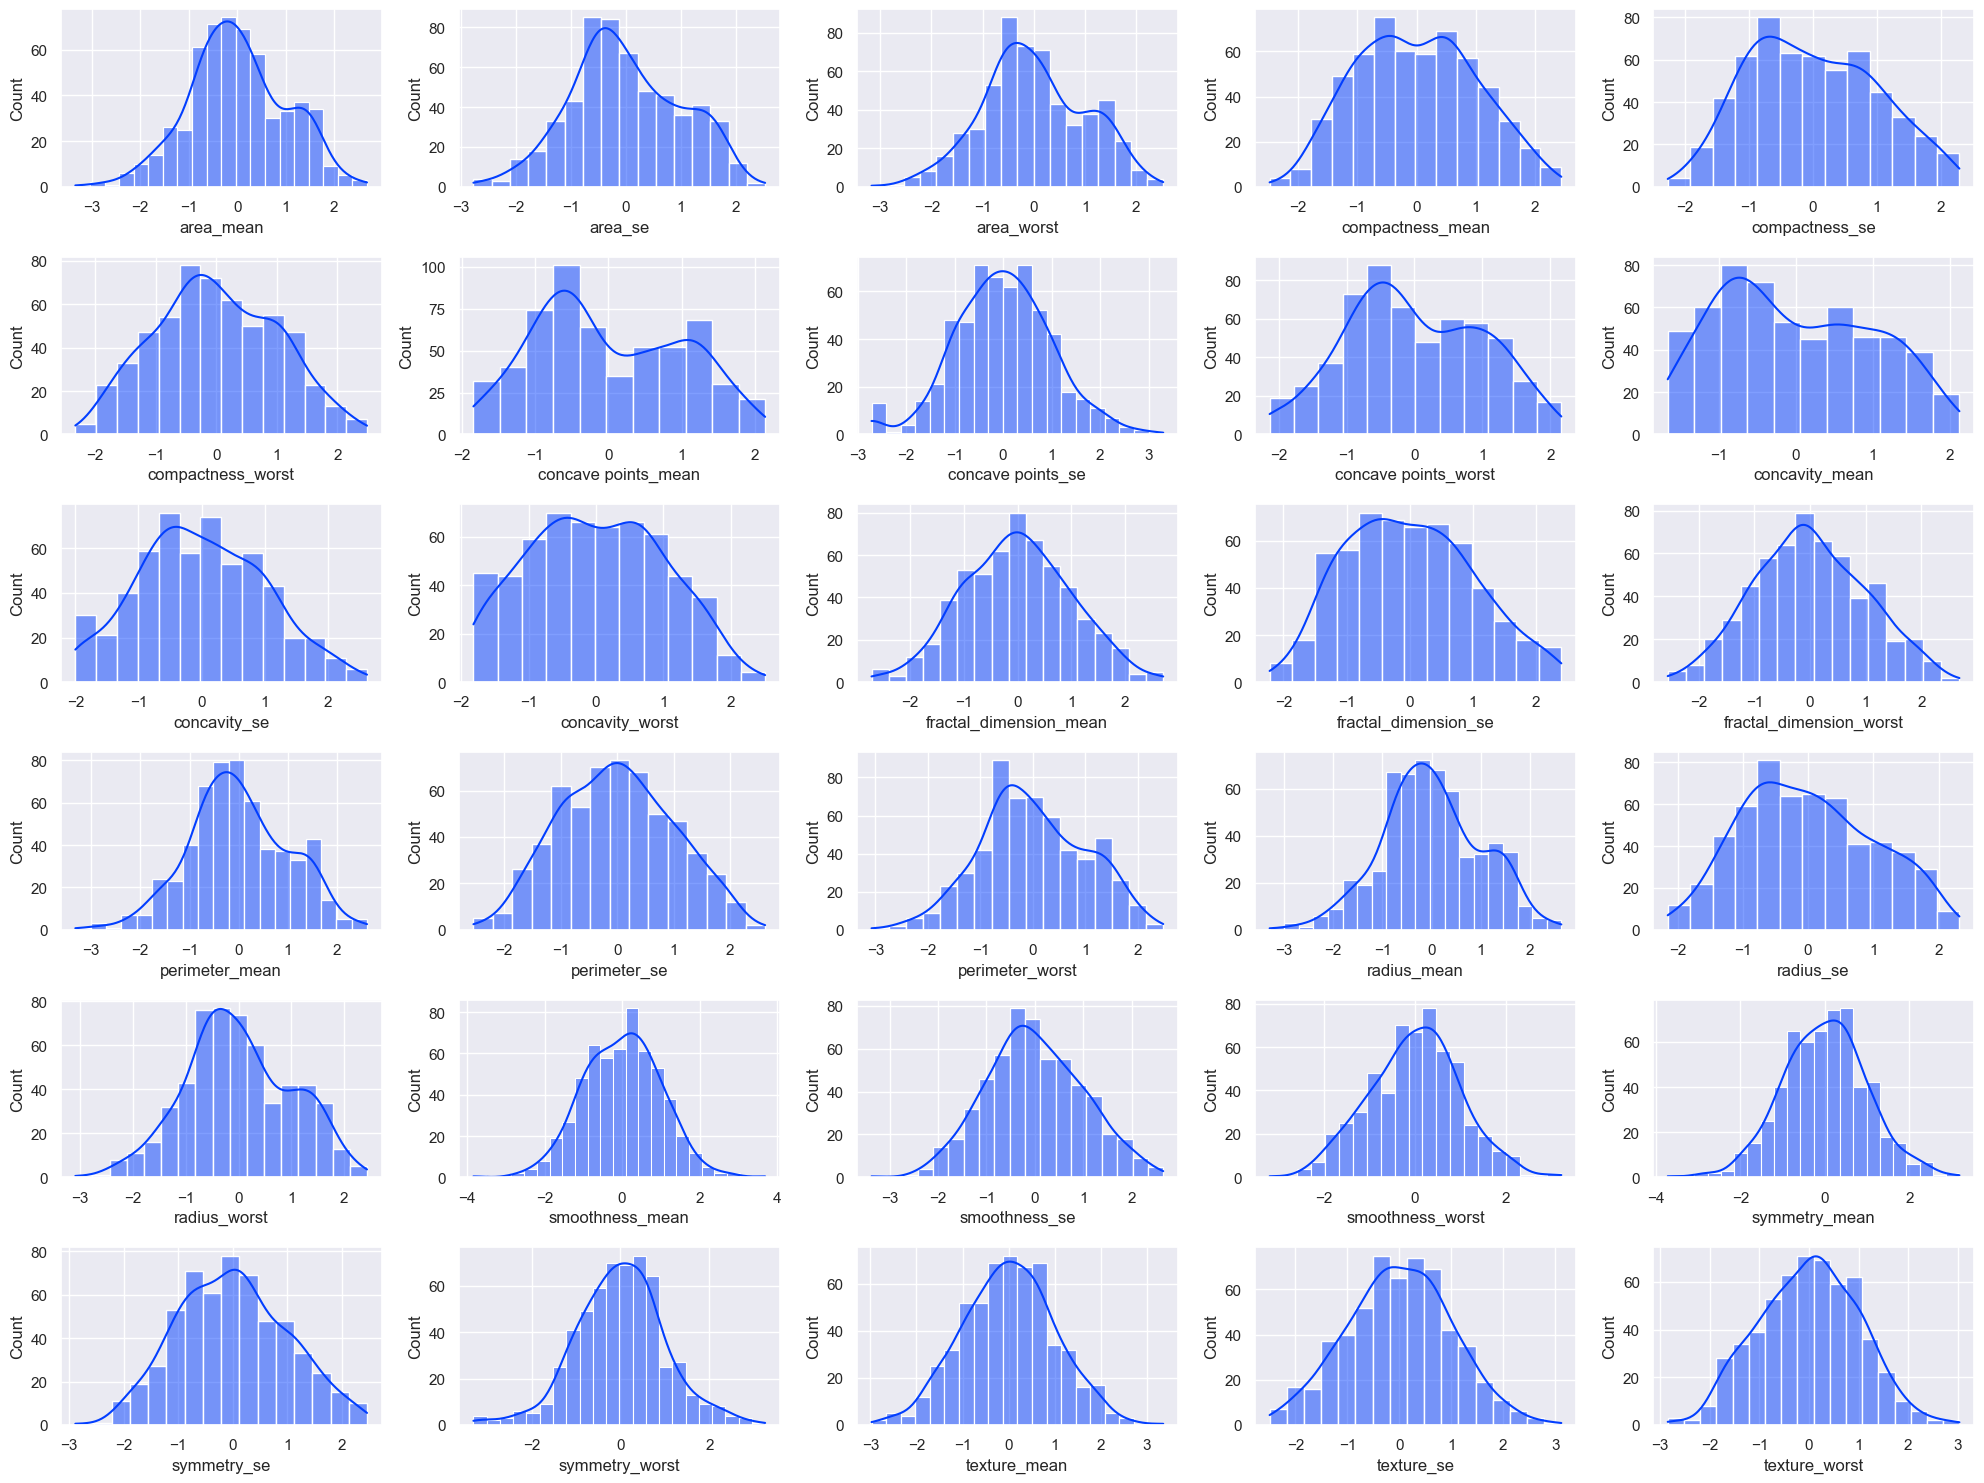

In [27]:
fig, axs = plt.subplots(6, 5, figsize=(20, 15))

for ax, coluna in zip(axs.flatten(), X.columns):
    sns.histplot(x=coluna, ax=ax, data=df_scaled, kde=True)

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

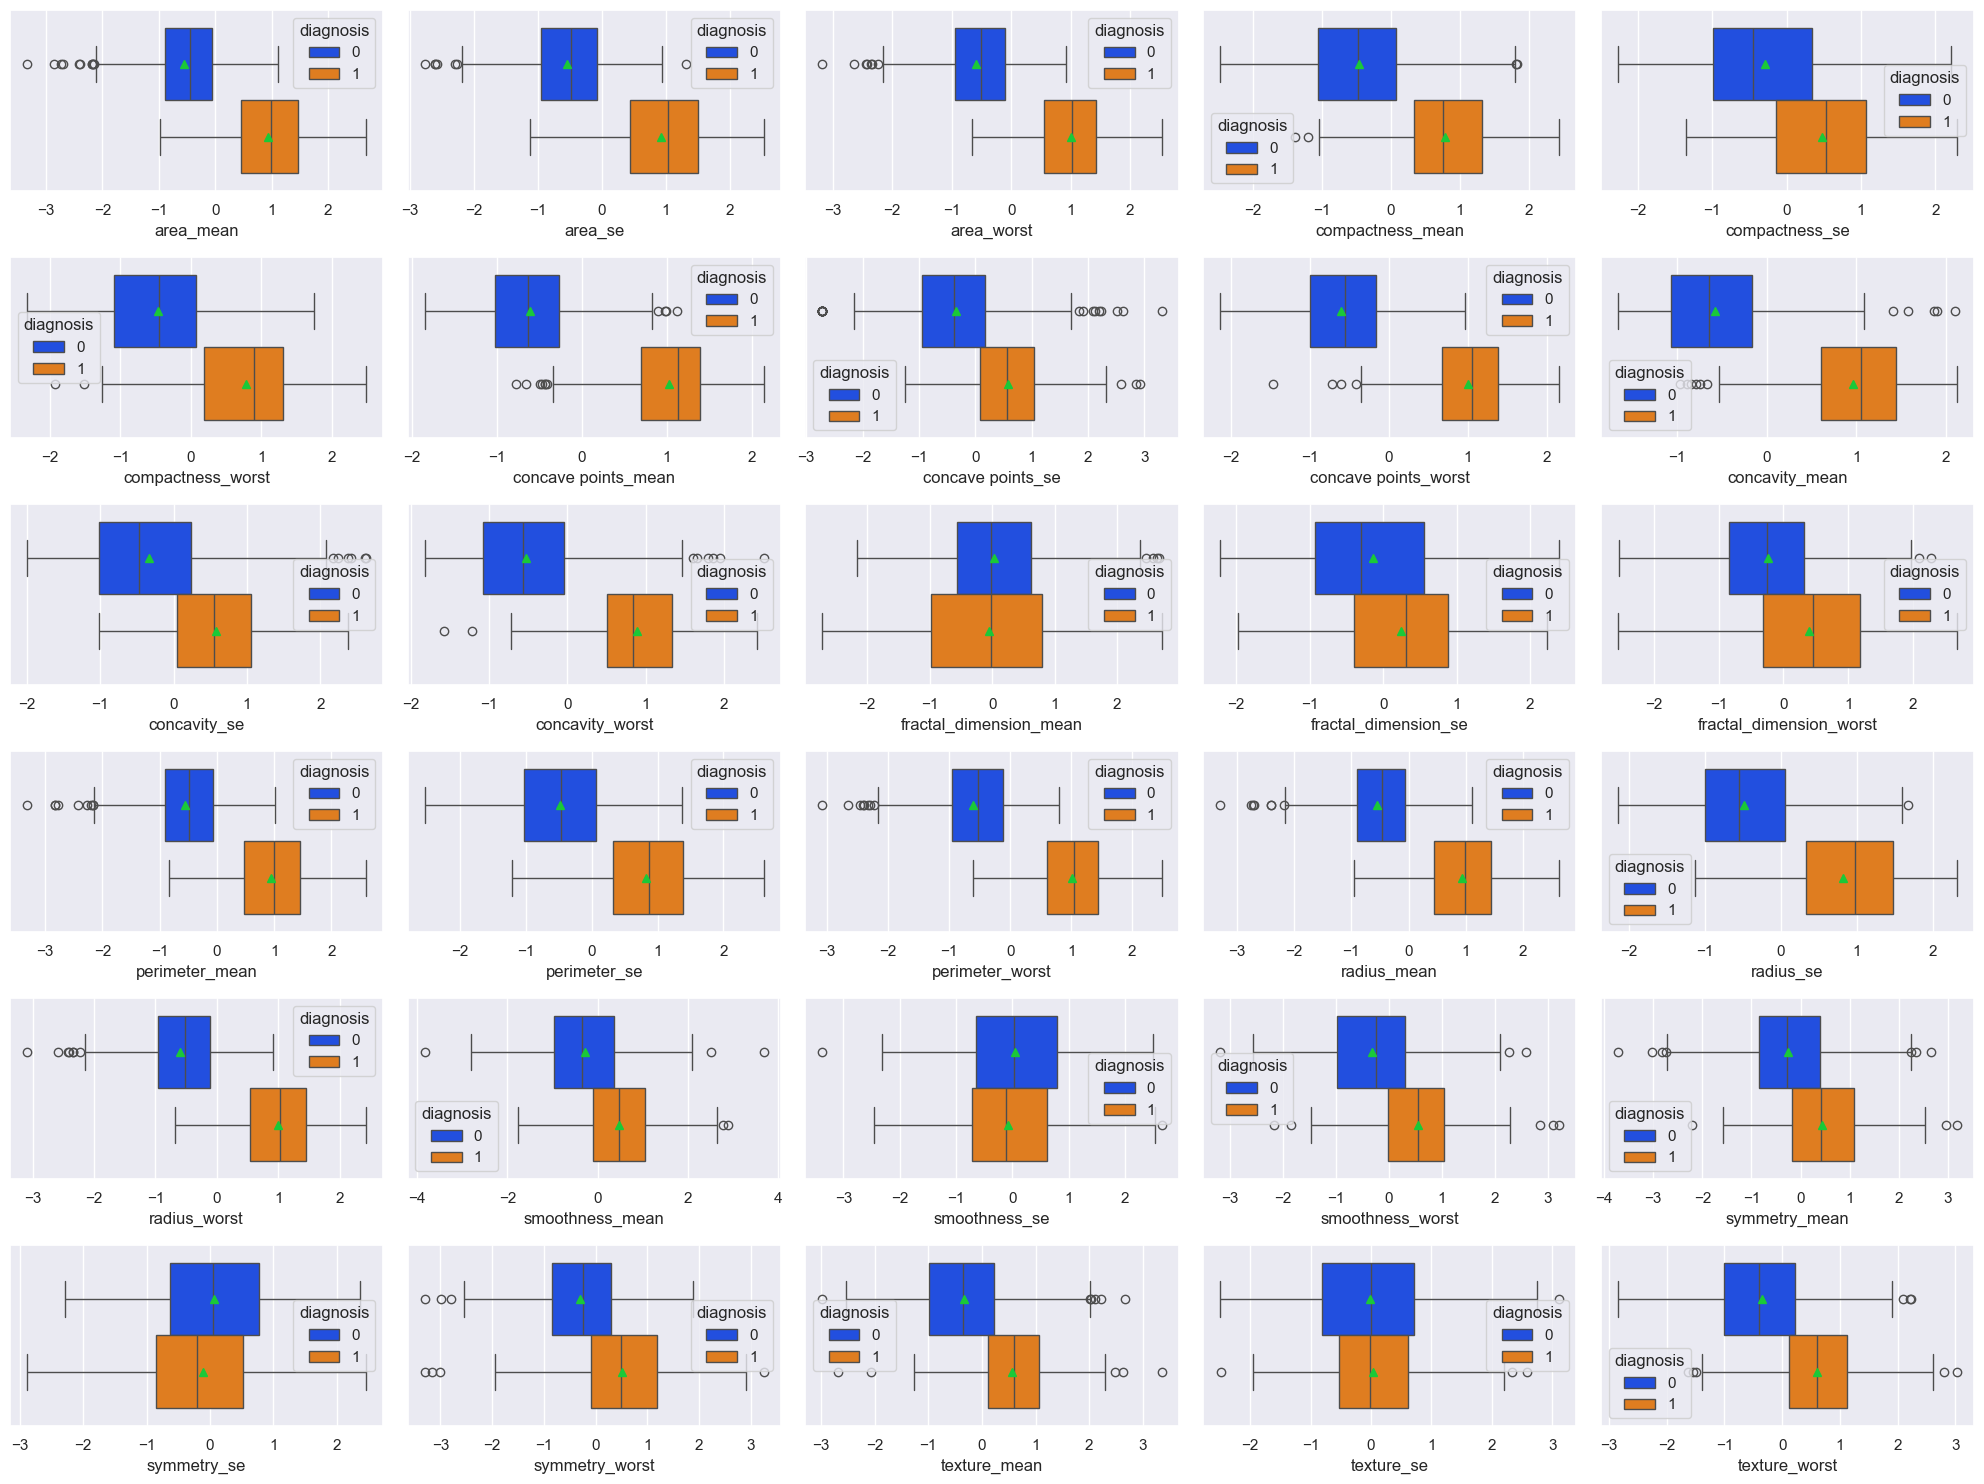

In [29]:
fig, axs = plt.subplots(6, 5, figsize=(20,15))

for ax, coluna in zip(axs.flatten(),X_scaled.columns):
    sns.boxplot(x=coluna, ax=ax, data=df_scaled, showmeans=True, hue="diagnosis")

plt.tight_layout()
plt.show